In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("TelcoCustomerChurn.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [5]:
df.isnull().sum()

CustomerID                          0
Gender                              0
Age                                 0
Under30                             0
SeniorCitizen                       0
Married                             0
Dependents                          0
NumberofDependents                  0
Country                             0
State                               0
City                                0
ZipCode                             0
Latitude                            0
Longitude                           0
Population                          0
Quarter                             0
ReferredaFriend                     0
Number_of_Referrals                 0
TenureinMonths                      0
Offer                            3877
PhoneService                        0
AvgMonthlyLongDistanceCharges       0
MultipleLines                       0
InternetService                     0
InternetType                     1526
AvgMonthlyGBDownload                0
OnlineSecuri

In [46]:
df['Quarter'].unique()

array(['Q3'], dtype=object)

In [18]:
df["ChurnLabel"].value_counts(normalize=True) # not much imbalanced

ChurnLabel
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [19]:
df["ChurnLabel"] = df["ChurnLabel"].map({"Yes":1, "No":0})

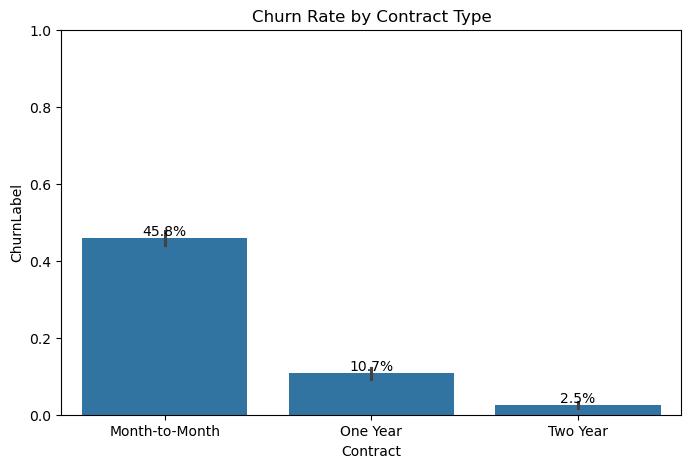

In [20]:
# contract vs churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
ax = sns.barplot(x="Contract", y="ChurnLabel", data=df)

for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Churn Rate by Contract Type")
plt.ylim(0,1)
plt.show()

# month-to-month contract type customers churn the most => commitment issues 

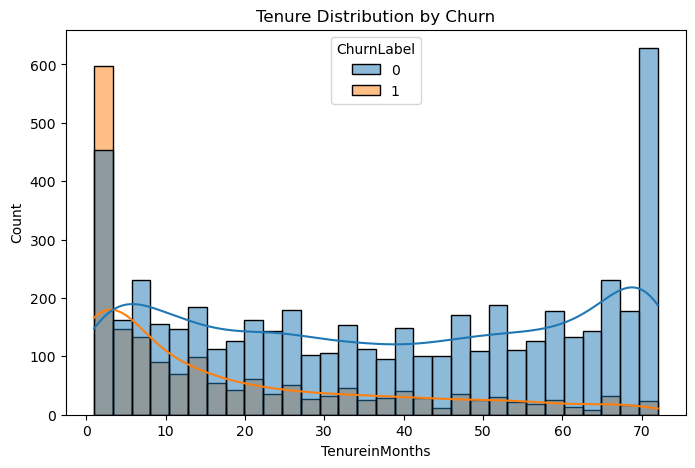

In [21]:
# tenure vs chhurnlabel 
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="TenureinMonths", hue="ChurnLabel", bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()


# this shows customers churn the most in early months. AS tenure increases churn decrease.

# insights => new customers are risky  &  old ones are loyal

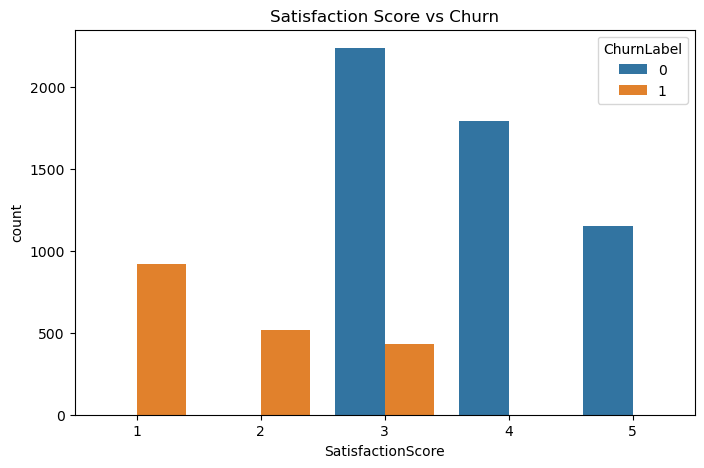

In [22]:
# satisfaction vs churnlabel

plt.figure(figsize=(8,5))
sns.countplot(x="SatisfactionScore", hue="ChurnLabel", data=df)
plt.title("Satisfaction Score vs Churn")
plt.show()

# this shows that satisfaction score plays the big role in churn . lower the satisfaction score higher the churn.

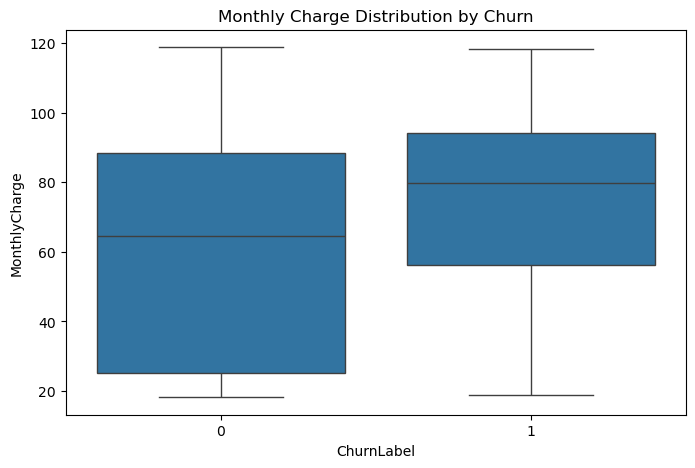

In [24]:
# monthly charges vs churnlabel
plt.figure(figsize=(8,5))
sns.boxplot(x="ChurnLabel", y="MonthlyCharge", data=df)
plt.title("Monthly Charge Distribution by Churn")
plt.show()

# Customers paying higher monthly charges are more likely to churn. Expensive plans increases churn rate.

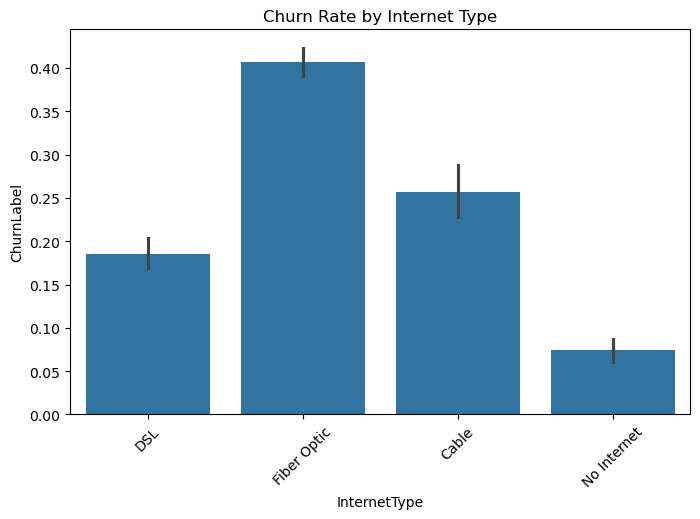

In [47]:
# internet type vs churn label
df["InternetType"] = df["InternetType"].fillna("No Internet")

plt.figure(figsize=(8,5))
sns.barplot(x="InternetType", y="ChurnLabel", data=df)
plt.title("Churn Rate by Internet Type")
plt.xticks(rotation=45)
plt.show()

# fiber optic customers churn the most. customer with no internet service churn the least.

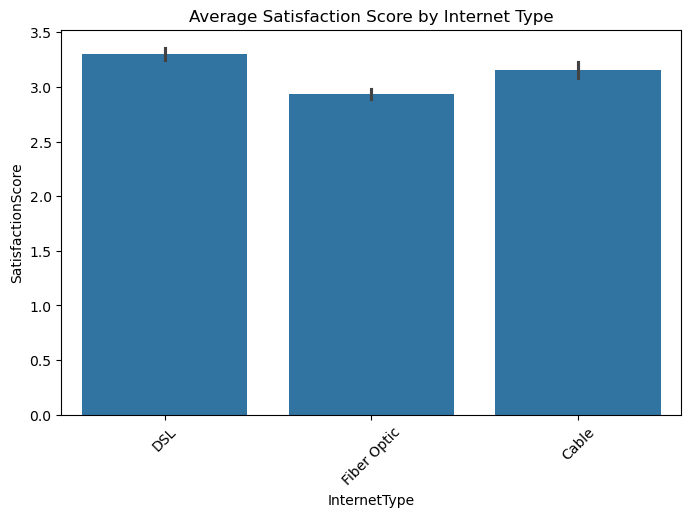

In [27]:
# Satisfaction Score vs internet Type

plt.figure(figsize=(8,5))
sns.barplot(x="InternetType", y="SatisfactionScore", data=df)
plt.title("Average Satisfaction Score by Internet Type")
plt.xticks(rotation=45)
plt.show()

# this shows fiber optic users have low satisfaction score so company needs to fix its fiber optic service to reduce churn.

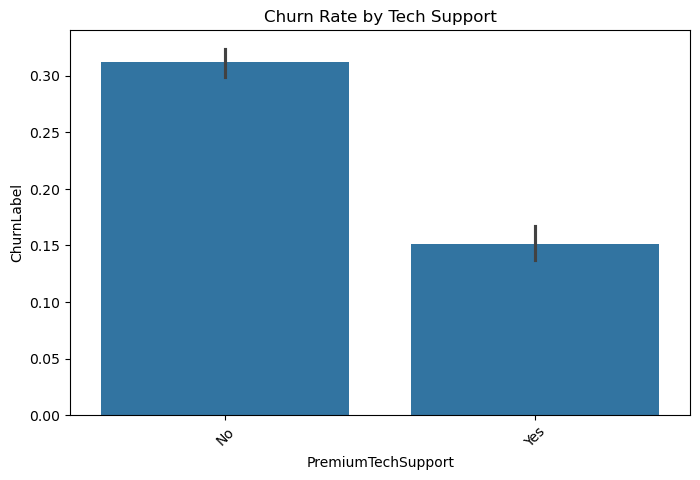

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(y="ChurnLabel", x="PremiumTechSupport", data=df)
plt.title("Churn Rate by Tech Support")
plt.xticks(rotation=45)
plt.show()


"""
Insight:

Customers without Premium Tech Support show higher churn rates,
suggesting that enhanced customer assistance is associated with
improved customer retention.

However, since some customers with Premium Tech Support still churn,
this indicates that tech support alone does not fully explain churn.
Other factors such as pricing, contract type, or overall service
quality may also significantly contribute to customer churn.
"""



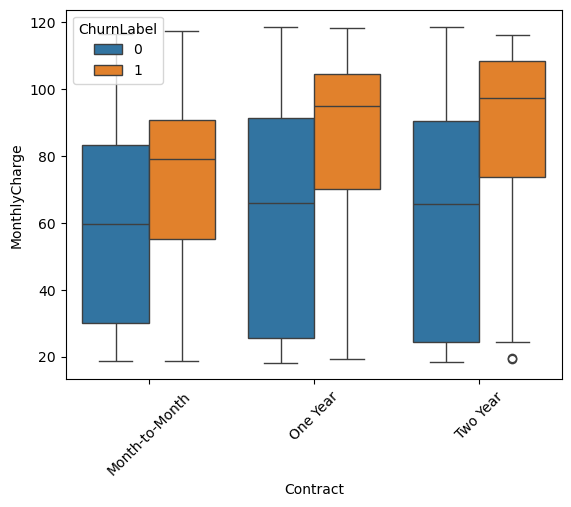

In [35]:
# Churn by Contract + Monthly Charges (Interaction Check)

sns.boxplot(x="Contract", y="MonthlyCharge", hue="ChurnLabel", data=df)
plt.xticks(rotation=45)
plt.show()

"""
Across all contract types, customers who churn exhibit higher median monthly charges compared to retained customers. 
This indicates that pricing sensitivity is a strong contributor to churn. 
While long-term contracts reduce churn overall, higher monthly charges still increase churn risk regardless of contract duration.

The interaction between contract type and monthly charges suggests that 
month-to-month customers with high charges represent the highest-risk churn segment.

"""

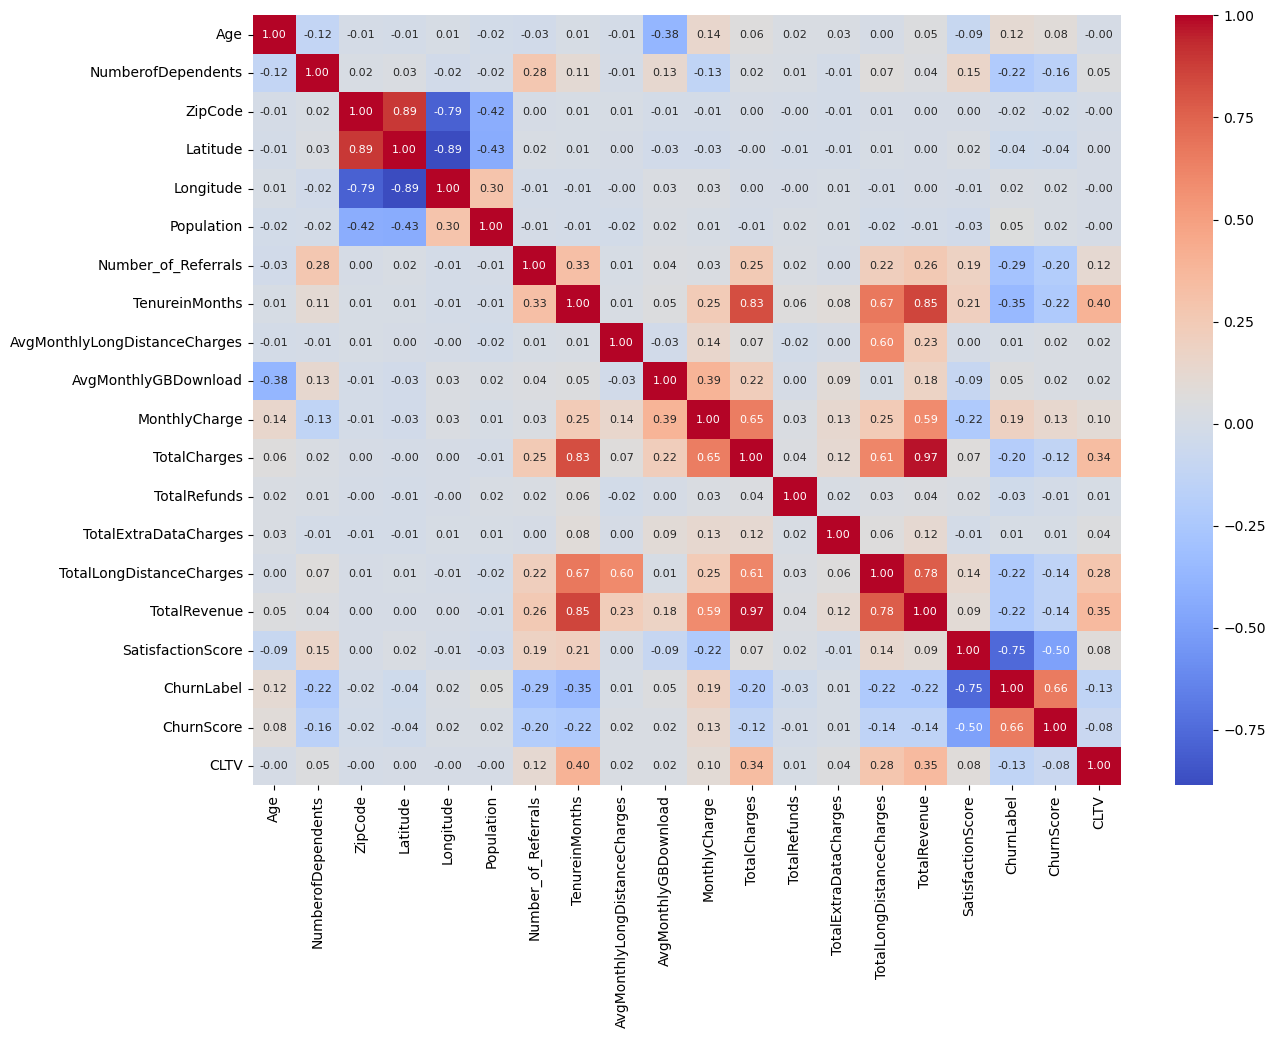

In [40]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",        # only 2 decimal places
    cmap="coolwarm",
    annot_kws={"size":8}  # smaller font
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

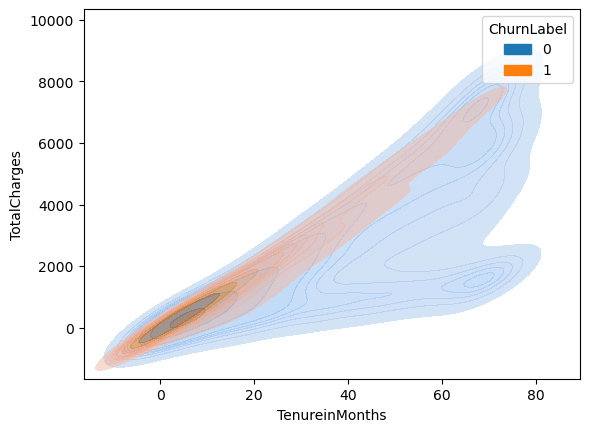

In [44]:
sns.kdeplot(
    x="TenureinMonths",
    y="TotalCharges",
    hue="ChurnLabel",
    data=df,
    fill=True,
    alpha=0.5
)
plt.show()

"""
The density plot shows that churned customers are concentrated in the lower tenure region,
indicating that customers are more likely to churn early in their lifecycle. In contrast, 
retained customers dominate higher tenure and higher total charge regions, 
suggesting that longer customer relationships significantly reduce churn risk.

"""